## **Giảm chiều và trực quan hóa chữ số viết tay bằng t-SNE.**

In [10]:
import pandas as pd  
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 
from core.evaluation import load_optdigits_csv, run_evaluation  
from core.tsne_numpy import TSNE  
import matplotlib.image as mpimg


#### **Tiền xử lí dữ liệu**

In [2]:
# Đọc dữ liệu hai file data gốc  
train = pd.read_csv (r'data\raw\optdigits.tra' , header= None )
test = pd.read_csv (r'data\raw\optdigits.tes' , header= None )  

print ('==== Value null ==== ')  
print ( "Null train :" ,train.isnull ().sum ( ).sum ()) 
print ( "Null test :" , test.isnull ().sum ().sum ())

print ('Shape train :' , train.shape)  
print ('Shape test :', test.shape )
# Gôp file thông qua concat 
data = pd.concat ([train  , test ] , ignore_index= True  ,axis= 0 )  

print ('=' * 20 )  
print ('Shape data : ' ,  data.shape  )    



==== Value null ==== 
Null train : 0
Null test : 0
Shape train : (3823, 65)
Shape test : (1797, 65)
Shape data :  (5620, 65)


In [3]:
# Lưu dataset sau xử lí  

column_names= [f'Pixel_{i}' for i in range (1 , 65) ]  
data.columns =  column_names + ['label']  
data.to_csv (r'data\processed\optdigits.csv') 

data

,Pixel_1,Pixel_2,Pixel_3,Pixel_4,Pixel_5,Pixel_6,Pixel_7,Pixel_8,Pixel_9,Pixel_10,...,Pixel_56,Pixel_57,Pixel_58,Pixel_59,Pixel_60,Pixel_61,Pixel_62,Pixel_63,Pixel_64,label
0,0,1,6,15,12,1,0,0,0,7,...,0,0,0,6,14,7,1,0,0,0
1,0,0,10,16,6,0,0,0,0,7,...,0,0,0,10,16,15,3,0,0,0
2,0,0,8,15,16,13,0,0,0,1,...,0,0,0,9,14,0,0,0,0,7
3,0,0,0,3,11,16,0,0,0,0,...,0,0,0,0,1,15,2,0,0,4
4,0,0,5,14,4,0,0,0,0,0,...,0,0,0,4,12,14,7,0,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5615,0,0,4,10,13,6,0,0,0,1,...,0,0,0,2,14,15,9,0,0,9
5616,0,0,6,16,13,11,1,0,0,0,...,0,0,0,6,16,14,6,0,0,0
5617,0,0,1,11,15,1,0,0,0,0,...,0,0,0,2,9,13,6,0,0,8
5618,0,0,2,10,7,0,0,0,0,0,...,0,0,0,5,12,16,12,0,0,9


#### **Traning và tiến hành thử nghiệm đánh giá kết quả trực quan dữ liệu**

In [5]:
# Load dataset 
X, y  = load_optdigits_csv (r'data\processed\optdigits.csv') 

X_test = X[:2000]  # Thử nghiệm với 2000 mẫu dữ liệu 
y_test = y[:2000]
# Đánh giá thử nghiệm trên nhiều giá perflexity và visualize kết quả 
results = run_evaluation(
    X_test,
    y_test ,
    perplexities=[5, 10, 15, 20, 25, 30, 45, 50, 60, 70, 80, 90, 100],
    n_iter=500,
    random_state=42,
    output_dir="outputs",
    verbose=True )    





=== Perplexity = 5 ===
Vòng lặp    0: KL divergence = 100.591683
Vòng lặp  100: KL divergence = 79.173033
Vòng lặp  200: KL divergence = 73.491733
Vòng lặp  300: KL divergence = 1.685042
Vòng lặp  400: KL divergence = 1.027862
Vòng lặp  499: KL divergence = 0.842386
  KL Divergence   : 0.841149
  Runtime (s)     : 60.26
  Trustworthiness : 0.948917

=== Perplexity = 10 ===
Vòng lặp    0: KL divergence = 92.641749
Vòng lặp  100: KL divergence = 71.544031
Vòng lặp  200: KL divergence = 67.426161
Vòng lặp  300: KL divergence = 1.388674
Vòng lặp  400: KL divergence = 0.868198
Vòng lặp  499: KL divergence = 0.742134
  KL Divergence   : 0.741336
  Runtime (s)     : 64.90
  Trustworthiness : 0.984014

=== Perplexity = 15 ===
Vòng lặp    0: KL divergence = 87.918725
Vòng lặp  100: KL divergence = 67.336085
Vòng lặp  200: KL divergence = 64.321677
Vòng lặp  300: KL divergence = 1.231542
Vòng lặp  400: KL divergence = 0.777817
Vòng lặp  499: KL divergence = 0.681718
  KL Divergence   : 0.681136

d:\t-SNE\core\evaluation.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Đã lưu 4 hình vào: outputs\figures


In [6]:
# Kết quả đánh từng perflexity  
print (results )

    perplexity  kl_divergence  runtime_sec  trustworthiness
0            5       0.841149    60.263247         0.948917
1           10       0.741336    64.902098         0.984014
2           15       0.681136    55.683092         0.993240
3           20       0.640092    54.763354         0.995545
4           25       0.596478    56.277607         0.996855
5           30       0.577071    57.560935         0.997093
6           45       0.467548   143.116618         0.998047
7           50       0.441998   154.103127         0.998217
8           60       0.392190   242.231045         0.998450
9           70       0.349039   169.382573         0.998594
10          80       0.312239   218.218347         0.998683
11          90       0.276323   265.032916         0.998710
12         100       0.254121   240.824767         0.998711


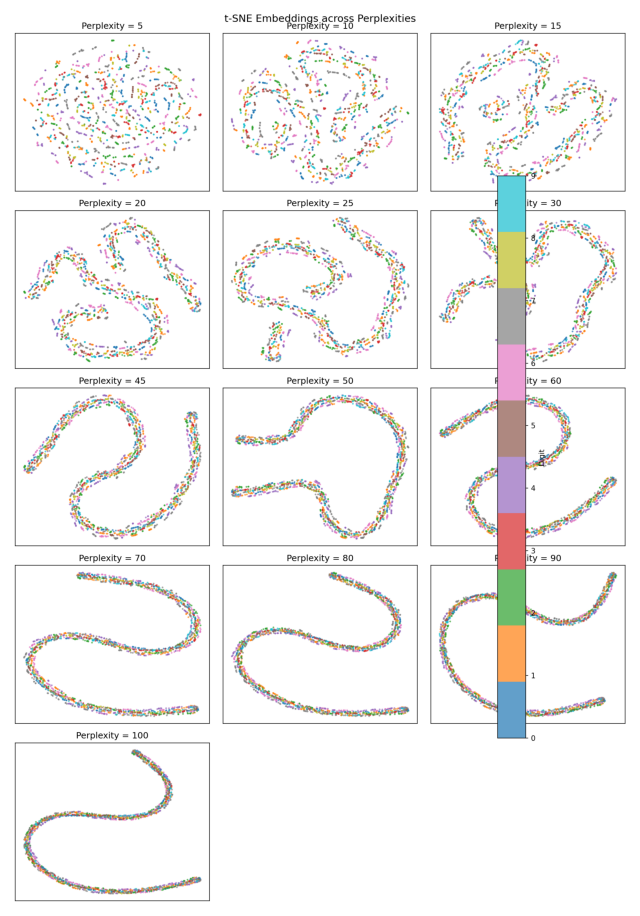

In [15]:
# Kết quả trực quan hóa dữ thoe từng perflexity 

img = mpimg.imread(r"outputs\figures\tsne_perplexity_grid.png")

plt.figure(figsize=(8, 29))
plt.imshow(img)
plt.axis("off")
plt.show()

####  **--> Mặc dù các giá trị perplexity lớn từ 70–100 cho KL Divergence thấp và Trustworthiness rất cao, embedding có xu hướng co thành các dải cong khiến các lớp chữ số trộn lẫn và khó quan sát. Perplexity = 10 được chọn cho trực quan hóa cuối cùng vì biểu diễn cấu trúc dữ liệu rõ ràng hơn, đồng thời vẫn duy trì Trustworthiness cao và KL Divergence ở mức tốt.**

### **Giảm và chiều trực quan hóa toàn bộ dữ liệu với perfexlity 10**

In [17]:
# Chạy trên toàn bộ dataset với perflexity 70

model_t_SNE =  TSNE(
    n_components=2,
    perplexity=10,
    n_iter=1000,
    random_state=42,
    verbose=True
)

dataset_2d  = model_t_SNE.fit_tranform (X)  

Vòng lặp    0: KL divergence = 105.044302
Vòng lặp  100: KL divergence = 82.190509
Vòng lặp  200: KL divergence = 75.044405
Vòng lặp  300: KL divergence = 2.435203
Vòng lặp  400: KL divergence = 1.454034
Vòng lặp  500: KL divergence = 1.163762
Vòng lặp  600: KL divergence = 1.022158
Vòng lặp  700: KL divergence = 0.937048
Vòng lặp  800: KL divergence = 0.879339
Vòng lặp  900: KL divergence = 0.837309
Vòng lặp  999: KL divergence = 0.805432


#### **Giảm chiều cho toàn bộ dataset với Perflexity = 25**

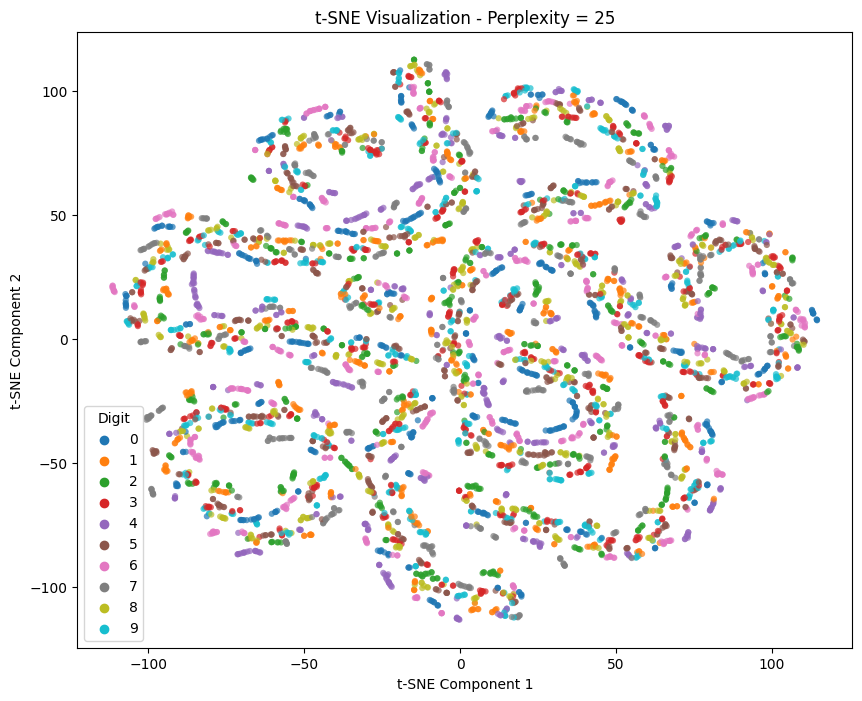

In [18]:
# Trực quan hóa dữ liệu dưới dạng 2d 

# Tạo DataFrame để trực quan hóa
df_2d = pd.DataFrame({
    "Component 1": dataset_2d[:, 0],
    "Component 2": dataset_2d[:, 1],
    "Label": y
})

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_2d,
    x="Component 1",
    y="Component 2",
    hue="Label",
    palette="tab10",
    s=20,
    alpha=0.7,
    linewidth=0
)

plt.title("t-SNE Visualization - Perplexity = 25")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Digit")

# Lưu ảnh kết quả trực quan 
plt.savefig(
    "outputs/figures/tsne_perplexity_25.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()